### Illustration of how Repeated Convolution of $\chi_{[-1/2, 1/2]}$ creates B-splines

We know that B-spline of order $n$ can be defined as

Define the unit box as
$$
B_1(x) = \chi_{[-1/2,\,1/2)} =
\begin{cases}
1, & x \in [-1/2,\,1/2),\\
0, & \text{else}.
\end{cases}
$$

Higher–order splines are defined by repeated self–convolution,
$$
B_{n+1}(x) = (B_1 * B_n)(x)
= \underbrace{\chi_{[-1/2,\,1/2)} * \chi_{[-1/2,\,1/2)} * \cdots * \chi_{[-1/2,\,1/2)}}_{n+1\ \text{times}}.
$$

Here we illustrate this

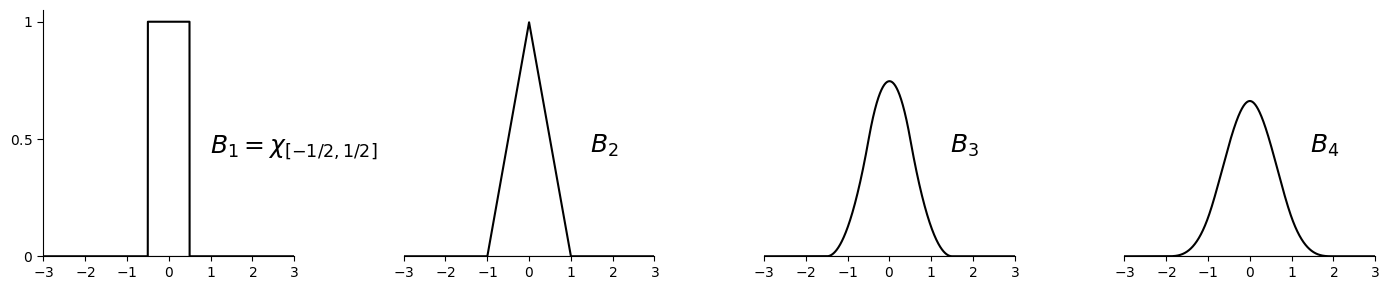

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Domain
x = np.linspace(-4, 4, 3000)
dx = x[1] - x[0]

# Indicator function on [-1/2, 1/2]
def box(x):
    return np.where(np.abs(x) <= 0.5, 1.0, 0.0)

# Initialize
B = box(x)
splines = [B.copy()]

# Number of convolutions
num_convolutions = 3

for _ in range(num_convolutions):
    B = np.convolve(B, box(x), mode='same') * dx
    splines.append(B.copy())

# Labels
labels = [
    r"$B_1 = \chi_{[-1/2,1/2]}$",
    r"$B_2$",
    r"$B_3$",
    r"$B_4$",
    r"$B_5$"
]

# Plot
fig, axes = plt.subplots(1, len(splines), figsize=(14, 3), sharey=True)


fontsize = 18
for i, (ax, s) in enumerate(zip(axes, splines)):
    ax.plot(x, s, color="black")

    ax.axhline(0, linewidth=0.8, color="black")
    if i == 0:
        ax.text(1, 0.5, labels[i], 
                ha='center', va='top', 
                transform=ax.transAxes, 
                fontsize=fontsize)
    else:
        ax.text(0.8, 0.5, labels[i], 
                ha='center', va='top', 
                transform=ax.transAxes, 
                fontsize=fontsize)
        
    ax.set_xlim(-3, 3)
    ax.set_ylim(0, 1.05)

    ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
    ax.set_xticklabels([r"$-3$", r"$-2$", r"$-1$", r"$0$", r"$1$", r"$2$", r"$3$"])

    if i == 0:
        ax.spines['left'].set_visible(True)
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels([r"$0$", r"$0.5$", r"$1$"])
        ax.tick_params(axis='y', which='both',
                       left=True, labelleft=True,
                       direction='out', length=4, width=0.8)
    else:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', which='both',
                       left=False, labelleft=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.savefig("bspline_construction.pdf", dpi=500)
plt.show()